<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Florencia Vanella


# Consigna

En el repositorio PDStestbench encontrará tres tipos de señales registradas:

- *Electrocardiograma (ECG)* En el archivo ECG_TP4.mat encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
- *Pletismografía (PPG)* El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
- *Audio* Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.
Los detalles de cómo acceder a dichos registros los pueden encontrar en *lectura_sigs.py*

#### Se pide:

#### 1) Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

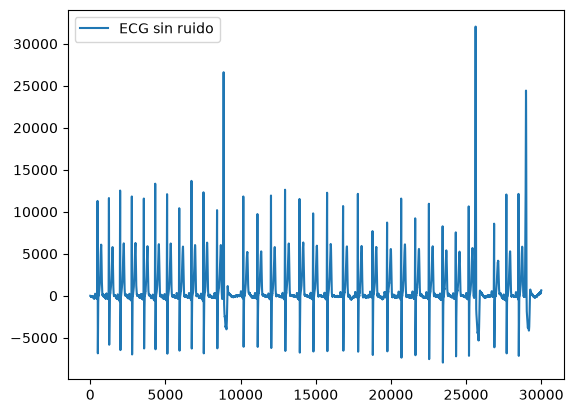

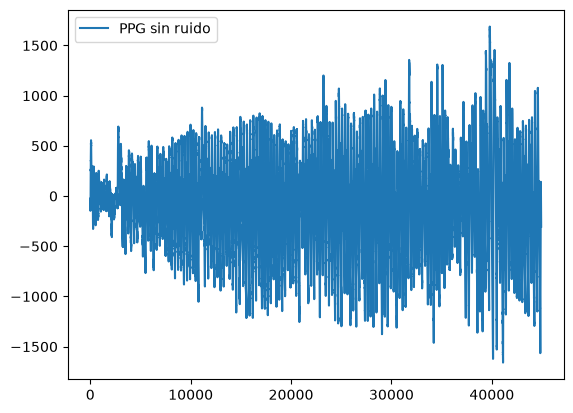

In [10]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io.wavfile import write


##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG sin ruido
##################

ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead, label='ECG sin ruido')
plt.legend()


####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')

plt.figure()
plt.plot(ppg, label='PPG sin ruido')
plt.legend()

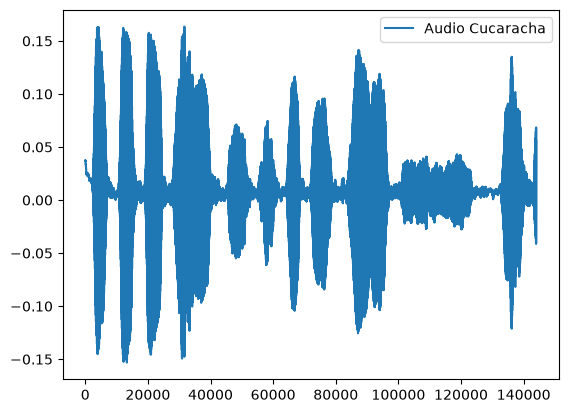

In [8]:
####################
# Lectura de audio #
####################

# Cargar el archivo CSV como un array de NumPy
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
# fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
# fs_audio, wav_data = sio.wavfile.read('silbido.wav')

plt.figure()
plt.plot(wav_data, label='Audio Cucaracha' )
plt.legend()
# si quieren oirlo, tienen que tener el siguiente módulo instalado
# pip install sounddevice
# import sounddevice as sd
# sd.play(wav_data, fs_audio)

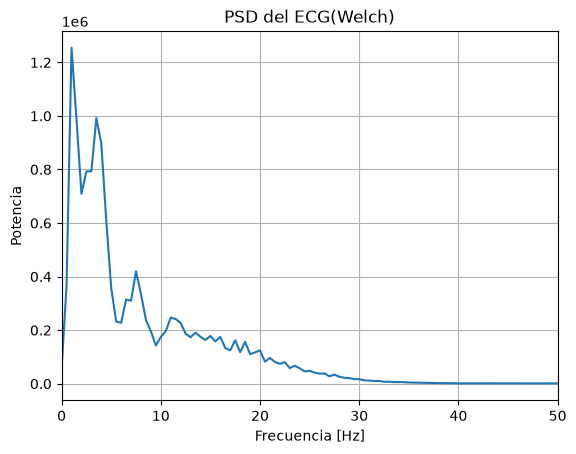

In [11]:
#Ejercicio 1 (Welch)

#1) Welch para ECG

# f = vector de frecuencias (eje X)
# psd = densidad espectral de potencia (eje Y)
f_ecg, psd_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=2000)

plt.figure()
plt.plot(f_ecg, psd_ecg)
plt.title('PSD del ECG(Welch)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.xlim(0, 50)  # Le hacemos zoom de 0 a 50 Hz porque ahí está lo importante del ECG
plt.grid(True)
plt.show()

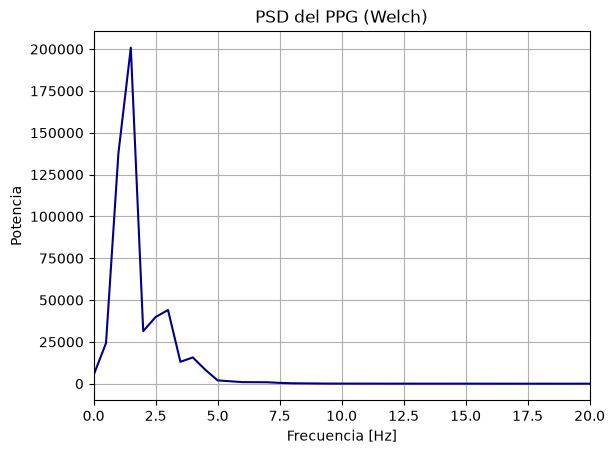

In [12]:
# 2. Welch para PPG
f_ppg, psd_ppg = sig.welch(ppg, fs=fs_ppg, nperseg=800)

plt.figure()
plt.plot(f_ppg, psd_ppg, color='darkblue')
plt.title('PSD del PPG (Welch)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.xlim(0, 20)  # El PPG tiene componentes aún más lentas (0-15 Hz)
plt.grid(True)
plt.show()

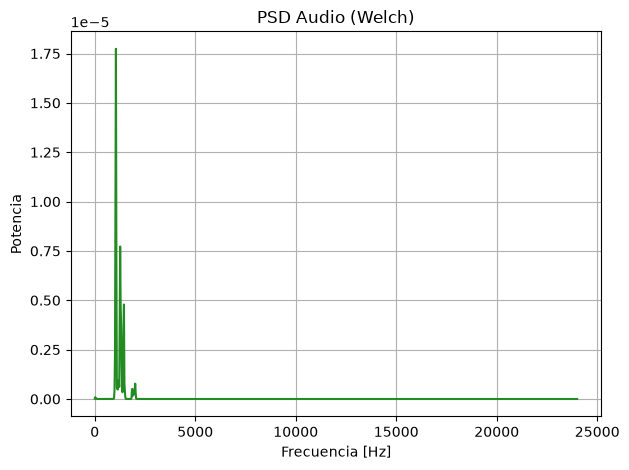

In [6]:
# 3. Welch para Audio
audio_data = wav_data.astype(float)
if audio_data.ndim > 1:
    audio_data = audio_data[:, 0]  # Nos quedamos con un canal si es estéreo
f_audio, psd_audio = sig.welch(audio_data, fs=fs_audio, nperseg=2048)

plt.figure()
plt.plot(f_audio, psd_audio, color='forestgreen')
plt.title('PSD Audio (Welch)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.grid(True)

plt.tight_layout()
plt.show()



Se observa claramente cómo la naturaleza de cada señal determina el rango de frecuencias donde concentra su potencia.

-ECG: Presenta sus componentes principales en el rango de $0$ a $30Hz$, con picos prominentes en la zona de $1Hz$ a $2Hz$ que se corresponden directamente con el ritmo cardíaco fundamental (aproximadamente $60$ a $120bpm$).
    
-PPG: Es una señal mecánica/fluídica. Mide cómo la pared de una arteria se infla y desinfla al paso de un líquido (la sangre). Como la elasticidad de los vasos y el paso de un fluido denso son procesos mecánicos mucho más lentos y amortiguados, el PPG casi no tiene variaciones rápidas, su contenido espectral es aún más acotado, concentrando casi toda la energía por debajo de los $4Hz$.
    
-Audio ("La Cucaracha"): A diferencia de las señales biomédicas, no posee componentes continuas ni de muy baja frecuencia. Toda su energía se desplaza hacia la banda audible, mostrando crestas pronunciadas entre $1000Hz$ y $2000Hz$ producidas por las notas de la melodía y sus armónicos.

#### 2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.


    RESULTADOS DE ANCHO DE BANDA (95% POTENCIA)
ECG (Pasa Bajo)   : BW =  22.50 Hz  | Rango: 0.00 Hz a 22.50 Hz
PPG (Pasa Bajo)   : BW =   4.00 Hz  | Rango: 0.00 Hz a 4.00 Hz
Audio (Pasa Banda): BW = 960.94 Hz  | Rango: 1007.81 Hz a 1968.75 Hz


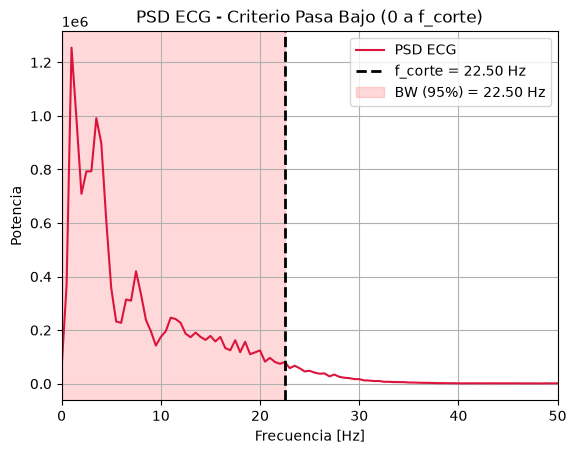

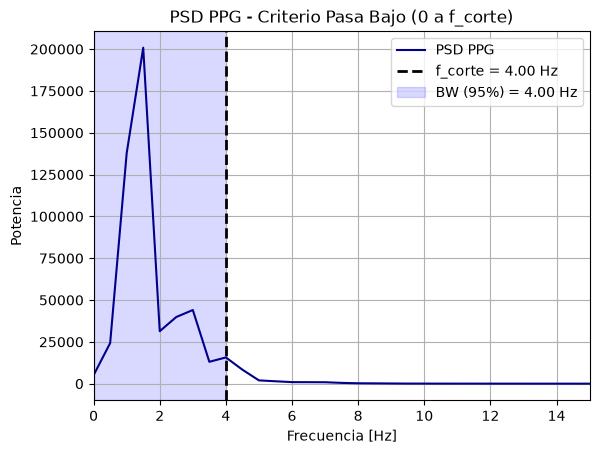

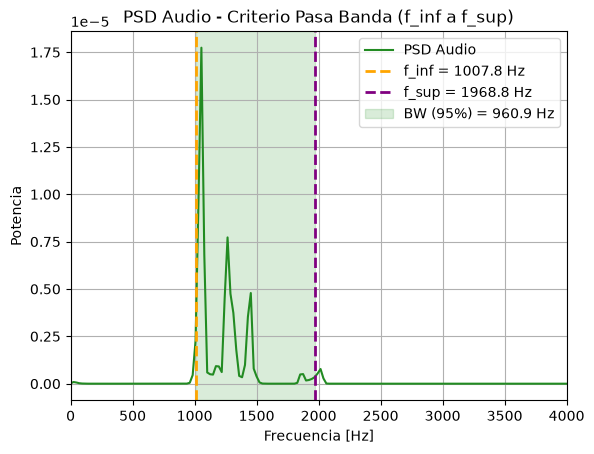

In [2]:
# CÁLCULO BW

# 1. ECG (Criterio Pasa Bajo)

# Paso A: Potencia total
P_total_ecg = np.sum(psd_ecg)

# Paso B: Vector de potencia acumulada
P_acum_ecg = np.cumsum(psd_ecg)

# Paso C: Buscamos la primera frecuencia donde la acumulación llega al 95%
meta_ecg = 0.95 * P_total_ecg

#busca el primer índice exacto donde la suma acumulada alcanzó o superó el 95% de la potencia tota
posicion_corte_ecg = np.where(P_acum_ecg >= meta_ecg)[0][0]

# Paso D: Extraemos las frecuencias y el ancho de banda
f_inf_ecg = 0.0
f_sup_ecg = f_ecg[posicion_corte_ecg]
bw_ecg = f_sup_ecg - f_inf_ecg


# -----------------------------------------------------------------------------
# 2. PPG (Criterio Pasa Bajo)
# -----------------------------------------------------------------------------
# Paso A: Potencia total
P_total_ppg = np.sum(psd_ppg)

# Paso B: Vector de potencia acumulada
P_acum_ppg = np.cumsum(psd_ppg)

# Paso C: Buscamos donde llega al 95%
meta_ppg = 0.95 * P_total_ppg
posicion_corte_ppg = np.where(P_acum_ppg >= meta_ppg)[0][0]

# Paso D: Extraemos las frecuencias y el ancho de banda
f_inf_ppg = 0.0
f_sup_ppg = f_ppg[posicion_corte_ppg]
bw_ppg = f_sup_ppg - f_inf_ppg


# -----------------------------------------------------------------------------
# 3. Audio (Criterio Pasa Banda)
# -----------------------------------------------------------------------------
# Paso A: Potencia total
P_total_audio = np.sum(psd_audio)

# Paso B: Vector de potencia acumulada
P_acum_audio = np.cumsum(psd_audio)

# Paso C: Definimos las metas del 2.5% (límite inferior) y 97.5% (límite superior)
meta_inf_audio = 0.025 * P_total_audio
meta_sup_audio = 0.975 * P_total_audio

# Paso D: Buscamos las posiciones de corte
posicion_inf_audio = np.where(P_acum_audio >= meta_inf_audio)[0][0]
posicion_sup_audio = np.where(P_acum_audio >= meta_sup_audio)[0][0]

# Paso E: Extraemos frecuencias y ancho de banda
f_inf_audio = f_audio[posicion_inf_audio]
f_sup_audio = f_audio[posicion_sup_audio]
bw_audio = f_sup_audio - f_inf_audio


print("\n==================================================")
print("    RESULTADOS DE ANCHO DE BANDA (95% POTENCIA)")
print("==================================================")
print(f"ECG (Pasa Bajo)   : BW = {bw_ecg:6.2f} Hz  | Rango: 0.00 Hz a {f_sup_ecg:.2f} Hz")
print(f"PPG (Pasa Bajo)   : BW = {bw_ppg:6.2f} Hz  | Rango: 0.00 Hz a {f_sup_ppg:.2f} Hz")
print(f"Audio (Pasa Banda): BW = {bw_audio:6.2f} Hz  | Rango: {f_inf_audio:.2f} Hz a {f_sup_audio:.2f} Hz")
print("==================================================")

# =============================================================================
# GRAFICACIÓN CON ANCHO DE BANDA VISUALIZADO
# =============================================================================

# 1. Gráfico ECG (Pasa Bajo)
plt.figure()
plt.plot(f_ecg, psd_ecg, color='crimson', label='PSD ECG')
plt.axvline(f_sup_ecg, color='black', linestyle='--', linewidth=2, label=f'f_corte = {f_sup_ecg:.2f} Hz')
plt.axvspan(0, f_sup_ecg, color='red', alpha=0.15, label=f'BW (95%) = {bw_ecg:.2f} Hz')
plt.title('PSD ECG - Criterio Pasa Bajo (0 a f_corte)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.xlim(0, 50)
plt.grid(True)
plt.legend()
plt.show()

# 2. Gráfico PPG (Pasa Bajo)
plt.figure()
plt.plot(f_ppg, psd_ppg, color='darkblue', label='PSD PPG')
plt.axvline(f_sup_ppg, color='black', linestyle='--', linewidth=2, label=f'f_corte = {f_sup_ppg:.2f} Hz')
plt.axvspan(0, f_sup_ppg, color='blue', alpha=0.15, label=f'BW (95%) = {bw_ppg:.2f} Hz')
plt.title('PSD PPG - Criterio Pasa Bajo (0 a f_corte)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.xlim(0, 15)
plt.grid(True)
plt.legend()
plt.show()

# 3. Gráfico Audio (Pasa Banda)
plt.figure()
plt.plot(f_audio, psd_audio, color='forestgreen', label='PSD Audio')
plt.axvline(f_inf_audio, color='orange', linestyle='--', linewidth=2, label=f'f_inf = {f_inf_audio:.1f} Hz')
plt.axvline(f_sup_audio, color='purple', linestyle='--', linewidth=2, label=f'f_sup = {f_sup_audio:.1f} Hz')
plt.axvspan(f_inf_audio, f_sup_audio, color='green', alpha=0.15, label=f'BW (95%) = {bw_audio:.1f} Hz')
plt.title('PSD Audio - Criterio Pasa Banda (f_inf a f_sup)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia')
plt.xlim(0, 4000)  # Zoom hasta 4000 Hz donde está lo audible de la canción
plt.grid(True)
plt.legend()
plt.show()

Criterio Pasa Bajo (ECG y PPG): Al no descartar las frecuencias continuas ($0Hz$), el ancho de banda se consideró como la frecuencia de corte $f_corte$ que acumula el $95%$ de la potencia total.
Para el ECG se obtuvo un ancho de banda de $22.50Hz$ y para el PPG de $4Hz$. Esto confirma experimentalmente que para procesar o filtrar estas señales fisiológicas sin distorsionar su morfología basta con utilizar frecuencias de corte relativamente bajas.

Criterio Pasa Banda (Audio): Para el audio se descartaron las colas del $2.5%$ inferior y $2.5%$ superior para evitar tomar frecuencias sin información relevante. El intervalo obtenido entre $1007.8Hz$ y $1968.8Hz$ encierra la banda de energía principal, dando un ancho de banda de $960.9Hz$.